# Importações e Configurações Globais

In [1]:
import argparse
import json
import os
import sys
import time
import warnings
from pathlib import Path
from typing import Optional

# ── Carrega variaveis do arquivo .env (API keys, etc)
try:
    from dotenv import load_dotenv
    load_dotenv()  # le .env no diretorio atual e injeta em os.environ
except ImportError:
    pass  # se python-dotenv nao estiver instalado, pula silenciosamente

import matplotlib
# Configura o backend do matplotlib para ser compatível com Jupyter de forma robusta
try:
    matplotlib.use('module://matplotlib_inline.backend_inline')
except Exception:
    try:
        matplotlib.use('inline')
    except Exception:
        try:
            matplotlib.use('Agg')
        except Exception:
            pass

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# PyTorch — MLP com Dropout e Weight Decay
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print('[AVISO] PyTorch nao encontrado. Apenas Logistic Regression sera treinada.')

# httpx — cliente HTTP assincrono para o servidor MCP remoto (opcional)
try:
    import httpx
    HTTPX_AVAILABLE = True
except ImportError:
    HTTPX_AVAILABLE = False

# Silence irrelevant warnings
warnings.filterwarnings('ignore')
try:
    if hasattr(sys.stdout, 'reconfigure'):
        sys.stdout.reconfigure(encoding='utf-8')
except Exception:
    pass

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURACOES GLOBAIS
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = Path('static/stock_details_5_years.csv')
if not DATA_PATH.exists():
    # Procura em caminhos alternativos possíveis no ambiente do Jupyter
    potential_paths = [
        Path('../Downloads/static/stock_details_5_years.csv'),
        Path('/home/ana/Downloads/static/stock_details_5_years.csv'),
        Path('neurofinance/static/stock_details_5_years.csv'),
        Path('../static/stock_details_5_years.csv')
    ]
    for p in potential_paths:
        if p.exists():
            DATA_PATH = p
            break

DEFAULT_COMPANY  = 'GOOGL'
SIGNAL_THRESHOLD = 0.65
N_SPLITS         = 5
HORIZON_DAYS     = 5
RANDOM_STATE     = 42


# Cliente MCP Alpha Vantage (Sentimento de Notícias)

In [2]:
class AlphaVantageMCPClient:
    """
    Cliente de integracao com o servidor MCP da Alpha Vantage para busca
    de sentimento de noticias financeiras.

    ─────────────────────────────────────────────────────────────────────────
    ARQUITETURA MCP DA ALPHA VANTAGE (conforme https://mcp.alphavantage.co)
    ─────────────────────────────────────────────────────────────────────────

    O servidor MCP oficial e acessivel em dois modos:

    1. REMOTO (HTTP/SSE — recomendado para agentes LLM):
       URL: https://mcp.alphavantage.co/mcp?apikey=SUA_CHAVE
       Protocolo: Model Context Protocol sobre HTTP com Server-Sent Events.
       Uso tipico: integrado a Claude, Cursor, VS Code, OpenAI Agents SDK.

    2. LOCAL (stdio — para ambiente de desenvolvimento):
       Comando: uvx marketdata-mcp-server SUA_CHAVE
       Protocolo: MCP sobre stdin/stdout.

    ─────────────────────────────────────────────────────────────────────────
    ESTRATEGIA DE INTEGRACAO PARA PIPELINES PYTHON AUTONOMOS
    ─────────────────────────────────────────────────────────────────────────

    O protocolo MCP e projetado para comunicacao LLM <-> ferramentas. Para
    pipelines ML autônomos (sem LLM intermediario), a abordagem mais estavel
    e chamar diretamente a REST API da Alpha Vantage, que e a mesma fonte
    de dados que o servidor MCP utiliza internamente.

    Este cliente implementa:
      - `fetch_sentiment_rest()`: chamada direta REST (primaria, sempre disponivel)
      - `fetch_sentiment_mcp_http()`: chamada via protocolo MCP/HTTP (avancado)

    ─────────────────────────────────────────────────────────────────────────
    CONFIGURACAO DA API KEY
    ─────────────────────────────────────────────────────────────────────────

    Para obter sua chave gratuita:
        https://www.alphavantage.co/support/#api-key

    Defina a chave de uma das seguintes formas (por ordem de precedencia):
        1. Variavel de ambiente:  export ALPHAVANTAGE_API_KEY="SUA_CHAVE"
        2. Argumento de linha:    --api-key SUA_CHAVE
        3. Construtor:            AlphaVantageMCPClient(api_key="SUA_CHAVE")

    ─────────────────────────────────────────────────────────────────────────
    ENDPOINT UTILIZADO: NEWS_SENTIMENT
    ─────────────────────────────────────────────────────────────────────────

    Ref: https://www.alphavantage.co/documentation/#news-sentiment

    Parametros:
        function   = "NEWS_SENTIMENT"
        tickers    = ticker da empresa (ex: "GOOGL")
        time_from  = data inicial no formato YYYYMMDDTHHMM (ex: "20230101T0000")
        time_to    = data final   no formato YYYYMMDDTHHMM (ex: "20231231T2359")
        sort       = "EARLIEST" (cronologico)
        limit      = 200 (max por chamada no plano gratuito)
        apikey     = sua chave Alpha Vantage

    Resposta:
        JSON com campo "feed": lista de artigos. Cada artigo tem "ticker_sentiment":
            [{ "ticker": "GOOGL",
               "relevance_score": "0.9",
               "ticker_sentiment_score": "0.25",   # -1.0 a 1.0
               "ticker_sentiment_label": "Somewhat Bullish" }]

    Score ranges (da documentacao oficial):
        x <= -0.35              -> Bearish
        -0.35 < x <= -0.15     -> Somewhat Bearish
        -0.15 < x <  0.15      -> Neutral
         0.15 <= x <  0.35     -> Somewhat Bullish
         x >= 0.35             -> Bullish
    """

    # ── URL base do servidor MCP remoto (Alpha Vantage)
    MCP_SERVER_URL  = "https://mcp.alphavantage.co/mcp"
    # ── URL base da REST API direta (usada pelo modo fallback)
    REST_API_URL    = "https://www.alphavantage.co/query"

    def __init__(self, api_key: Optional[str] = None):
        """
        Args:
            api_key: Chave da API Alpha Vantage.
                     Se None, tenta ler de ALPHAVANTAGE_API_KEY no ambiente.
        """
        self.api_key = (
            api_key
            or os.environ.get("ALPHAVANTAGE_API_KEY")
            or "demo"  # "demo" permite apenas exemplos fixos da AV
        )
        if self.api_key == "demo":
            print("  [MCP] ATENCAO: Usando api_key='demo'. Apenas dados de exemplo.")
            print("        Obtenha sua chave em https://www.alphavantage.co/support/#api-key")

    # ──────────────────────────────────────────────────────────────────────
    # METODO PRIMARIO: REST API direta (robusto, sem dependencias extras)
    # ──────────────────────────────────────────────────────────────────────
    def fetch_sentiment_rest(
        self,
        ticker: str,
        date_from: pd.Timestamp,
        date_to:   pd.Timestamp,
        relevance_threshold: float = 0.3,
    ) -> pd.Series:
        """
        Busca sentimento de noticias via REST API da Alpha Vantage e
        retorna um pd.Series indexado por data (sentimento medio diario).

        Chamadas em lotes mensais para respeitar o limite de 200 itens/req
        do plano gratuito e evitar timeouts.

        Args:
            ticker:               Simbolo da empresa (ex: "GOOGL")
            date_from:            Data de inicio
            date_to:              Data de fim
            relevance_threshold:  Score minimo de relevancia para incluir artigo

        Returns:
            pd.Series com index=date (DatetimeIndex) e values=sentiment_score medio,
            apenas para dias com cobertura. NaN inserido para dias sem noticias
            na juncao com o DataFrame principal.
        """
        import requests

        records = []
        rate_limited = False

        # ── Itera em janelas TRIMESTRAIS (em vez de mensais) para reduzir
        # o numero de requests. O plano free da Alpha Vantage permite
        # apenas 25 requests/dia. Com 5 anos de dados = 60 meses = 60 req
        # se fosse mensal. Trimestral = ~20 req, cabendo no limite diario.
        current = date_from.replace(day=1)
        req_count = 0
        while current <= date_to and not rate_limited:
            # Janela trimestral: avanca 3 meses por iteracao
            quarter_end = (current + pd.DateOffset(months=3) - pd.Timedelta(days=1))
            quarter_end = min(quarter_end.normalize(), date_to)
            t_from = current.strftime("%Y%m%dT0000")
            t_to   = quarter_end.strftime("%Y%m%dT2359")

            params = {
                "function":  "NEWS_SENTIMENT",
                "tickers":   ticker,
                "time_from": t_from,
                "time_to":   t_to,
                "sort":      "EARLIEST",
                "limit":     200,
                "apikey":    self.api_key,
            }

            try:
                resp = requests.get(self.REST_API_URL, params=params, timeout=30)
                resp.raise_for_status()
                data = resp.json()
                req_count += 1

                # Verifica rate limit
                if "Note" in data or "Information" in data:
                    msg = data.get("Note", data.get("Information", ""))
                    print(f"  [MCP/REST] Limite de API atingido ({req_count} req feitas). "
                          f"Intervalo coberto ate {current.date()}.")
                    print(f"             Resposta: {msg[:100]}")
                    rate_limited = True
                    break

                feed = data.get("feed", [])
                for article in feed:
                    pub_time = pd.to_datetime(
                        article.get("time_published", ""), format="%Y%m%dT%H%M%S",
                        errors="coerce"
                    )
                    if pd.isna(pub_time):
                        continue

                    for ts in article.get("ticker_sentiment", []):
                        if ts.get("ticker", "").upper() == ticker.upper():
                            rel_score = float(ts.get("relevance_score", 0))
                            if rel_score >= relevance_threshold:
                                records.append({
                                    "date":  pub_time.normalize(),
                                    "score": float(ts.get("ticker_sentiment_score", 0)),
                                    "relevance": rel_score,
                                })

                if req_count % 5 == 0:
                    print(f"    ... {req_count} req | {len(records)} artigos | ate {quarter_end.date()}")

            except Exception as exc:
                print(f"  [MCP/REST] Erro em {current.date()}: {exc}")

            # Pausa para respeitar rate limit (5 req/min no plano free)
            time.sleep(12.5)  # 5 req/min = 1 req a cada 12s
            current = quarter_end + pd.Timedelta(days=1)

        if not records:
            print(f"  [MCP/REST] Nenhuma noticia encontrada para {ticker}.")
            return pd.Series(dtype=float)

        df_sent = pd.DataFrame(records)
        # Media diaria ponderada pela relevancia
        daily = (
            df_sent.groupby("date")
            .apply(lambda g: np.average(g["score"], weights=g["relevance"]))
            .rename("sentiment")
        )
        print(f"  [MCP/REST] {len(records)} artigos -> {len(daily)} dias com sentimento.")
        return daily

    # ──────────────────────────────────────────────────────────────────────
    # METODO AVANCADO: Protocolo MCP HTTP/SSE (modo agente)
    # ──────────────────────────────────────────────────────────────────────
    def fetch_sentiment_mcp_http(
        self,
        ticker:    str,
        date_from: pd.Timestamp,
        date_to:   pd.Timestamp,
    ) -> pd.Series:
        """
        Chama o servidor MCP remoto da Alpha Vantage usando o protocolo
        JSON-RPC sobre HTTP (conforme especificacao MCP).

        IMPORTANTE: Esta abordagem e experimental para uso direto em Python.
        O servidor MCP da Alpha Vantage e projetado para ser consumido por
        clientes MCP (ex: Claude Desktop, Cursor, VS Code). Para pipelines
        Python autonomos, prefira `fetch_sentiment_rest()`.

        Como funciona o protocolo MCP HTTP:
            1. POST para o endpoint MCP com Content-Type: application/json
            2. Corpo: JSON-RPC com method="tools/call", params.name="TOOL_CALL"
            3. O servidor retorna o resultado da ferramenta como JSON

        Configuracao do servidor MCP remoto:
            URL: https://mcp.alphavantage.co/mcp?apikey=SUA_CHAVE

        Ref: https://mcp.alphavantage.co (secao "Remote Server Connection")
        Ref: https://github.com/alphavantage/alpha_vantage_mcp

        Fallback automatico para REST se httpx nao estiver disponivel.
        """
        if not HTTPX_AVAILABLE:
            print("  [MCP/HTTP] httpx nao instalado. Usando fallback REST.")
            return self.fetch_sentiment_rest(ticker, date_from, date_to)

        mcp_url = f"{self.MCP_SERVER_URL}?apikey={self.api_key}"

        # Payload JSON-RPC 2.0 para chamar a ferramenta NEWS_SENTIMENT via MCP
        # O servidor MCP da AV usa o padrao "Progressive Tool Discovery":
        #   - TOOL_LIST  -> lista ferramentas disponiveis
        #   - TOOL_CALL  -> invoca uma ferramenta especifica
        t_from = date_from.strftime("%Y%m%dT0000")
        t_to   = date_to.strftime("%Y%m%dT2359")

        payload = {
            "jsonrpc": "2.0",
            "id": 1,
            "method": "tools/call",
            "params": {
                "name": "TOOL_CALL",
                "arguments": {
                    "tool_name": "NEWS_SENTIMENT",
                    "arguments": {
                        "tickers":   ticker,
                        "time_from": t_from,
                        "time_to":   t_to,
                        "sort":      "EARLIEST",
                        "limit":     200,
                    }
                }
            }
        }

        try:
            with httpx.Client(timeout=30) as client:
                resp = client.post(
                    mcp_url,
                    json=payload,
                    headers={"Content-Type": "application/json"},
                )
                resp.raise_for_status()
                result = resp.json()

            # Extrai o conteudo de texto do resultado MCP
            content = result.get("result", {}).get("content", [])
            if content and isinstance(content, list):
                raw_text = content[0].get("text", "{}")
                data = json.loads(raw_text)
                # Processa como se fosse resposta REST
                records = []
                for article in data.get("feed", []):
                    pub_time = pd.to_datetime(
                        article.get("time_published", ""),
                        format="%Y%m%dT%H%M%S", errors="coerce"
                    )
                    if pd.isna(pub_time):
                        continue
                    for ts in article.get("ticker_sentiment", []):
                        if ts.get("ticker", "").upper() == ticker.upper():
                            records.append({
                                "date":  pub_time.normalize(),
                                "score": float(ts.get("ticker_sentiment_score", 0)),
                                "relevance": float(ts.get("relevance_score", 0.5)),
                            })

                if records:
                    df_sent = pd.DataFrame(records)
                    daily = (
                        df_sent.groupby("date")
                        .apply(lambda g: np.average(g["score"], weights=g["relevance"]))
                        .rename("sentiment")
                    )
                    print(f"  [MCP/HTTP] {len(records)} artigos -> {len(daily)} dias.")
                    return daily

        except Exception as exc:
            print(f"  [MCP/HTTP] Falha no protocolo MCP: {exc}. Usando fallback REST.")
            return self.fetch_sentiment_rest(ticker, date_from, date_to)

        return pd.Series(dtype=float)


def build_sentiment_feature(
    df_ohlcv: pd.DataFrame,
    ticker:   str,
    api_key:  Optional[str] = None,
    use_mcp_http: bool = False,
) -> pd.DataFrame:
    """
    Integra o score de sentimento diario ao DataFrame OHLCV.

    Alinhamento temporal:
        - O sentimento e alinhado por data ao DataFrame local.
        - Dias sem noticias recebem NaN, preenchido por forward-fill (5 dias)
          e depois zero (sentimento neutro). Essa estrategia de imputacao e
          conservadora: nao inventa otimismo/pessimismo quando nao ha dados.

    Cache local:
        - Os dados de sentimento sao salvos em static/sentiment_cache_{ticker}.json
        - Em execucoes futuras, o cache e carregado automaticamente
        - Isso evita esgotar o limite de 25 req/dia do plano free

    Args:
        df_ohlcv:     DataFrame com dados OHLCV indexado por Data
        ticker:       Ticker da empresa
        api_key:      Chave Alpha Vantage (None = tenta env var)
        use_mcp_http: Se True, usa protocolo MCP/HTTP (experimental)

    Returns:
        DataFrame com coluna 'sentiment' adicionada.
    """
    cache_path = Path(f"static/sentiment_cache_{ticker.upper()}.json")

    # ── Tenta carregar do cache local primeiro
    daily_sentiment = pd.Series(dtype=float)
    if cache_path.exists():
        try:
            with open(cache_path, "r", encoding="utf-8") as f:
                cache_data = json.load(f)
            daily_sentiment = pd.Series(cache_data["sentiment"], dtype=float)
            daily_sentiment.index = pd.to_datetime(daily_sentiment.index)
            daily_sentiment.name = "sentiment"
            print(f"\n  [Sentimento] Cache local carregado: {len(daily_sentiment)} dias")
            print(f"               Arquivo: {cache_path}")
        except Exception as exc:
            print(f"\n  [Sentimento] Erro ao ler cache: {exc}. Buscando via API...")
            daily_sentiment = pd.Series(dtype=float)

    # ── Se cache esta vazio ou nao existe, busca via API
    if daily_sentiment.empty:
        print(f"\n  [Sentimento] Buscando dados para {ticker} via Alpha Vantage MCP...")
        client = AlphaVantageMCPClient(api_key=api_key)

        date_from = df_ohlcv.index.min()
        date_to   = df_ohlcv.index.max()

        if use_mcp_http:
            daily_sentiment = client.fetch_sentiment_mcp_http(ticker, date_from, date_to)
        else:
            daily_sentiment = client.fetch_sentiment_rest(ticker, date_from, date_to)

        # ── Salva no cache para execucoes futuras
        if not daily_sentiment.empty:
            try:
                cache_path.parent.mkdir(parents=True, exist_ok=True)
                cache_dict = {
                    "ticker": ticker.upper(),
                    "created_at": pd.Timestamp.now().isoformat(),
                    "n_days": len(daily_sentiment),
                    "sentiment": {
                        str(k.date()): float(v) for k, v in daily_sentiment.items()
                    },
                }
                with open(cache_path, "w", encoding="utf-8") as f:
                    json.dump(cache_dict, f, indent=2, ensure_ascii=False)
                print(f"  [Sentimento] Cache salvo em: {cache_path}")
            except Exception as exc:
                print(f"  [Sentimento] Erro ao salvar cache: {exc}")

    # Juncao e imputacao
    df = df_ohlcv.copy()
    df["sentiment"] = daily_sentiment.reindex(df.index)

    # Forward-fill ate 5 dias: sentimento recente e relevante para a janela
    # de previsao de 5 dias uteis. Pesquisa em Behavioral Finance mostra
    # que sentimento de noticias tem meia-vida de 3-5 dias uteis.
    df["sentiment"] = df["sentiment"].ffill(limit=5)
    # Dias sem nenhuma cobertura = neutro (0.0)
    df["sentiment"] = df["sentiment"].fillna(0.0)

    coverage = (daily_sentiment.reindex(df.index).notna().sum() / len(df)) * 100
    print(f"  [Sentimento] Cobertura: {coverage:.1f}% dos dias de trading")
    return df



# ETL (Carga e Limpeza de Dados OHLCV)

In [3]:
def load_ohlcv(data_path: Path, company: str) -> pd.DataFrame:
    """
    Carrega e limpa dados OHLCV para uma empresa especifica.
    Retorna DataFrame indexado por Data, ordenado cronologicamente.
    """
    print(f"\n{'='*60}")
    print(f"  [ETL] Carregando dados: {company}")
    print(f"{'='*60}")

    df = pd.read_csv(data_path)
    df = df[df["Company"] == company].copy()

    if df.empty:
        avail = pd.read_csv(data_path, usecols=["Company"])["Company"].unique()[:10]
        raise ValueError(f"'{company}' nao encontrado. Exemplos: {avail.tolist()}")

    df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_localize(None).dt.normalize()
    df = df.sort_values("Date").reset_index(drop=True)
    df = df.drop(columns=["Dividends", "Stock Splits", "Company"])
    df = df.dropna(subset=["Open", "High", "Low", "Close", "Volume"])
    df = df[df["Volume"] > 0]

    print(f"  {len(df):,} dias uteis | {df['Date'].min().date()} -> {df['Date'].max().date()}")
    print(f"  Close: ${df['Close'].min():.2f} - ${df['Close'].max():.2f}")
    return df.set_index("Date")



## Carregando e mostrando os dados brutos

In [4]:
df_ohlcv = load_ohlcv(DATA_PATH, DEFAULT_COMPANY)
print(f'Shape do dataset após ETL: {df_ohlcv.shape}')
df_ohlcv.head()


  [ETL] Carregando dados: GOOGL
  1,258 dias uteis | 2018-11-29 -> 2023-11-29
  Close: $49.23 - $149.84
Shape do dataset após ETL: (1258, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2018-11-29,54.176498,55.007500,54.099998,54.729000,31004000
2018-11-30,54.781502,55.482498,54.159000,55.482498,59668000
2018-12-03,56.608002,56.750000,55.586498,55.818001,57532000
2018-12-04,55.649502,55.712002,53.039001,53.123501,45630000
2018-12-06,52.250000,53.971001,52.124001,53.903999,47436000


# Pré-processamento e Integração do Sentimento de Notícias

In [5]:
# Por padrão no notebook, desativamos o sentimento (USE_SENTIMENT=False) para evitar chamadas à API externa.
# Você pode alterar para True se tiver uma chave válida de API da Alpha Vantage configurada.
USE_SENTIMENT = False

if USE_SENTIMENT:
    df_preprocessed = build_sentiment_feature(df_ohlcv, DEFAULT_COMPANY, api_key=None)
else:
    df_preprocessed = df_ohlcv.copy()
    df_preprocessed['sentiment'] = 0.0
    print('[Sentimento] Preenchido com 0.0 (neutro)')

print(f'Shape do dataset após integração de sentimento: {df_preprocessed.shape}')
df_preprocessed.head()

[Sentimento] Preenchido com 0.0 (neutro)
Shape do dataset após integração de sentimento: (1258, 6)


,Open,High,Low,Close,Volume,sentiment
Date,,,,,,
2018-11-29,54.176498,55.007500,54.099998,54.729000,31004000,0.0
2018-11-30,54.781502,55.482498,54.159000,55.482498,59668000,0.0
2018-12-03,56.608002,56.750000,55.586498,55.818001,57532000,0.0
2018-12-04,55.649502,55.712002,53.039001,53.123501,45630000,0.0
2018-12-06,52.250000,53.971001,52.124001,53.903999,47436000,0.0


# Engenharia de Features (Extração de Padrões)

In [6]:
def engineer_features(df: pd.DataFrame, horizon: int = HORIZON_DAYS) -> pd.DataFrame:
    """
    Cria indicadores tecnicos e variavel alvo com horizonte de N dias.

    ── Indicadores (foco em volatilidade e momentum) ──────────────────────

    1. Log-Return diario:  ln(Close_t / Close_{t-1})
       Prefere-se log-return ao return simples: propriedades aditivas,
       simetria e robustez a outliers de precos extremos.

    2. Volatilidade rolante (7/21 dias): desvio padrao dos log-returns.
       Proxy do risco/incerteza percebido pelo mercado.

    3. Momentum (5/10/20 dias): log(Close_t / Close_{t-N}).
       Captura tendencias de curto e medio prazo.

    4. ATR normalizado (14 dias): Average True Range / Close.
       Mede a amplitude do movimento diario em termos relativos.

    5. RSI-14: oscilador de momentum 0-100.
       Identifica condicoes de sobrecompra/sobrevenda.

    6. Posicao relativa as SMAs (7/21/50):
       Sinais de cruzamento de medias moveis (cross-over).

    7. Volume ratio (7 dias): Volume / Volume_MA7.
       Pico de volume frequentemente confirma rompimentos.

    8. Lag-features (1, 2, 3 dias): return e volatilidade defasados.
       Incorporam autocorrelacao de curto prazo.

    9. Sentimento (se disponivel): score medio diario de noticias.

    ── Variavel Alvo (Horizonte de {horizon} dias) ─────────────────────────

    Target_5d = 1 se Close[t+5] > Close[t], senao 0.

    Por que 5 dias em vez de 1 dia?
    - Reduz o ruido diario (microestrutura de mercado)
    - Mais robusto a gaps de abertura e eventos pontuais
    - Melhor alinhamento com ciclos de tomada de decisao de um gestor
    - Sinal mais "suave" permite maior precision sem sacrificar recall

    IMPORTANTE: usamos shift(-horizon) apenas para criar o target.
    As features usam APENAS dados de t para tras (sem leakage).
    """
    print(f"\n{'='*60}")
    print(f"  [Features] Engenharia com target de {horizon} dias")
    print(f"{'='*60}")

    f = df.copy()

    # ── 1. Log-Return
    f["log_ret"] = np.log(f["Close"] / f["Close"].shift(1))

    # ── 2. Volatilidade rolante
    f["vol_7"]  = f["log_ret"].rolling(7).std()
    f["vol_21"] = f["log_ret"].rolling(21).std()

    # ── 3. Momentum em multiplas janelas
    f["mom_5"]  = np.log(f["Close"] / f["Close"].shift(5))
    f["mom_10"] = np.log(f["Close"] / f["Close"].shift(10))
    f["mom_20"] = np.log(f["Close"] / f["Close"].shift(20))

    # ── 4. ATR normalizado (14 dias)
    high_low   = f["High"] - f["Low"]
    high_close = (f["High"] - f["Close"].shift(1)).abs()
    low_close  = (f["Low"]  - f["Close"].shift(1)).abs()
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    f["atr_norm"] = tr.rolling(14).mean() / f["Close"]

    # ── 5. RSI-14
    delta    = f["Close"].diff()
    gain     = delta.clip(lower=0).rolling(14).mean()
    loss     = (-delta.clip(upper=0)).rolling(14).mean()
    f["rsi"] = 100 - 100 / (1 + gain / (loss + 1e-9))

    # ── 6. SMAs e posicao relativa
    for w in [7, 21, 50]:
        sma = f["Close"].rolling(w).mean()
        f[f"sma{w}_ratio"] = f["Close"] / sma - 1  # positivo = acima da media

    # ── 7. Volume ratio
    f["vol_ratio"] = f["Volume"] / f["Volume"].rolling(7).mean()

    # ── 8. Lags
    f["lag1_ret"]  = f["log_ret"].shift(1)
    f["lag2_ret"]  = f["log_ret"].shift(2)
    f["lag3_ret"]  = f["log_ret"].shift(3)
    f["lag1_vol7"] = f["vol_7"].shift(1)

    # ── 9. Variavel Alvo (horizonte de N dias)
    # Close[t+horizon] > Close[t] => Alta
    # shift(-horizon): o modelo NAO ve esses valores futuros nas features!
    f["Target"] = (f["Close"].shift(-horizon) > f["Close"]).astype(int)

    before = len(f)
    f = f.dropna()
    print(f"  Removidas {before - len(f)} linhas (warm-up + tail do target)")
    print(f"  Dataset: {len(f):,} amostras")
    print(f"  Target: Alta={f['Target'].sum()} ({f['Target'].mean()*100:.1f}%) "
          f"| Baixa={( f['Target']==0).sum()} ({(1-f['Target'].mean())*100:.1f}%)")
    return f


# Lista de features usadas no modelo (sem Target, sem OHLCV raw exceto Close)
FEATURE_COLS = [
    "log_ret", "vol_7", "vol_21",
    "mom_5", "mom_10", "mom_20",
    "atr_norm", "rsi",
    "sma7_ratio", "sma21_ratio", "sma50_ratio",
    "vol_ratio",
    "lag1_ret", "lag2_ret", "lag3_ret", "lag1_vol7",
    "sentiment",  # adicionada se disponivel, zerada caso contrario
]


## Extraindo padrões e mostrando a tabela final de features

In [7]:
df_feat = engineer_features(df_preprocessed, horizon=HORIZON_DAYS)
print(f'Shape do dataset final após Feature Engineering: {df_feat.shape}')
df_feat.head()


  [Features] Engenharia com target de 5 dias
  Removidas 49 linhas (warm-up + tail do target)
  Dataset: 1,209 amostras
  Target: Alta=690 (57.1%) | Baixa=519 (42.9%)
Shape do dataset final após Feature Engineering: (1209, 23)


,Open,High,Low,Close,Volume,sentiment,log_ret,vol_7,vol_21,mom_5,...,rsi,sma7_ratio,sma21_ratio,sma50_ratio,vol_ratio,lag1_ret,lag2_ret,lag3_ret,lag1_vol7,Target
Date,,,,,,,,,,,,,,,,,,,,,
2019-02-12,55.550499,56.643002,55.550499,56.379002,35036000,0.0,0.022838,0.017769,0.017166,-0.021313,...,59.770065,0.004952,0.023783,0.048103,0.760335,-0.000236,-0.003197,-0.015237,0.015049,0
2019-02-13,56.652000,57.142502,56.299999,56.431499,28042000,0.0,0.000931,0.015701,0.016829,0.005099,...,60.071304,0.007528,0.021331,0.048415,0.721160,0.022838,-0.000236,-0.003197,0.017769,0
2019-02-14,56.250000,56.806499,55.854500,56.459999,21106000,0.0,0.000505,0.015044,0.015427,0.020841,...,56.765864,0.010960,0.019971,0.048564,0.700192,0.000931,0.022838,-0.000236,0.015701,0
2019-02-15,56.965000,56.965000,55.835999,55.981499,27826000,0.0,-0.008511,0.011807,0.015589,0.015527,...,60.327182,0.002810,0.010018,0.039614,1.022091,0.000505,0.000931,0.022838,0.015044,0
2019-02-19,55.832001,56.481998,55.832001,56.325500,21980000,0.0,0.006126,0.009952,0.015535,0.021889,...,64.884261,0.006320,0.015030,0.044760,0.882964,-0.008511,0.000505,0.000931,0.011807,0


# Definição dos Modelos (Logistic Regression e MLP)

In [8]:
class LogisticRidgeModel:
    """
    Regressao Logistica com regularizacao L2 (Ridge) forte.

    Decisoes de design:
    - C = 0.01: penalidade forte (1/C = 100). Forca o modelo a aprender
      apenas padroes com sinal claro, ignorando ruido.
    - solver='lbfgs': eficiente para datasets medios (<5k amostras).
    - max_iter=1000: convergencia garantida com C pequeno.
    - class_weight='balanced': compensa assimetria entre classes.

    Por que L2 (Ridge) em vez de L1 (Lasso)?
    Em dados financeiros, raramente uma unica feature domina. L2 distribui
    o peso entre features correlacionadas (ex: vol_7 e vol_21), enquanto
    L1 zeraria uma delas arbitrariamente. Ridge resulta em modelos mais
    estaveis entre folds.
    """

    def __init__(self, C: float = 0.1):
        self.C = C
        self.model = LogisticRegression(
            C=C,
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
        self.scaler = StandardScaler()
        self.name   = f"LogReg-Ridge (C={C})"

    def fit(self, X: np.ndarray, y: np.ndarray):
        X_sc = self.scaler.fit_transform(X)
        self.model.fit(X_sc, y)
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return self.model.predict_proba(self.scaler.transform(X))[:, 1]

    def predict(self, X: np.ndarray, threshold: float = SIGNAL_THRESHOLD) -> np.ndarray:
        return (self.predict_proba(X) >= threshold).astype(int)


if TORCH_AVAILABLE:
    class MLP(nn.Module):
        """
        Rede Neural MLP simples com regularizacao via Dropout e Weight Decay.

        Arquitetura:
            Input -> Dense(64, BatchNorm, ReLU, Dropout(0.5))
                  -> Dense(32, BatchNorm, ReLU, Dropout(0.4))
                  -> Output(1, Sigmoid)

        Decisoes de regularizacao:
        - Dropout(0.5/0.4): a cada forward pass, 50%/40% dos neuronios sao
          desativados aleatoriamente. Isso impede co-adaptacao e forca o
          modelo a aprender representacoes redundantes e robustas.
        - Weight Decay (L2 nos pesos via Adam): penalidade nos pesos grandes,
          equivalente a regularizacao Ridge para redes neurais.
        - BatchNorm: estabiliza o treinamento e reduz a sensibilidade ao
          learning rate - especialmente importante com dados financeiros
          que mudam de escala ao longo do tempo.
        - Arquitetura pequena (2 camadas): underfitting ligeiro intencional.
          Em dados com ~1000 amostras, redes profundas overfitam facilmente.
        """

        def __init__(self, n_features: int):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(n_features, 64),
                nn.BatchNorm1d(64),
                nn.ReLU(),
                nn.Dropout(p=0.5),
                nn.Linear(64, 32),
                nn.BatchNorm1d(32),
                nn.ReLU(),
                nn.Dropout(p=0.4),
                nn.Linear(32, 1),
                nn.Sigmoid(),
            )

        def forward(self, x):
            return self.net(x).squeeze(1)

    class MLPModel:
        """
        Wrapper treinavel para o modulo MLP do PyTorch.

        Hiperparametros:
        - Adam com weight_decay=1e-3: regularizacao L2 nos pesos.
        - lr=1e-3: learning rate conservador.
        - epochs=100: convergencia com Dropout agressivo.
        - batch_size=32: ruido implicito benefico.
        """

        def __init__(self, n_features: int, epochs: int = 100, lr: float = 1e-3,
                     weight_decay: float = 1e-3, batch_size: int = 32):
            self.n_features   = n_features
            self.epochs       = epochs
            self.lr           = lr
            self.weight_decay = weight_decay
            self.batch_size   = batch_size
            self.scaler       = StandardScaler()
            self.model        = None
            self.name         = "MLP (Dropout=0.5, WeightDecay=1e-3)"

        def fit(self, X: np.ndarray, y: np.ndarray):
            X_sc = self.scaler.fit_transform(X)
            X_t  = torch.FloatTensor(X_sc)
            y_t  = torch.FloatTensor(y.astype(float))

            dataset = TensorDataset(X_t, y_t)
            loader  = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

            self.model = MLP(self.n_features)
            optimizer  = torch.optim.Adam(
                self.model.parameters(), lr=self.lr, weight_decay=self.weight_decay
            )
            criterion = nn.BCELoss()

            self.model.train()
            for _ in range(self.epochs):
                for xb, yb in loader:
                    optimizer.zero_grad()
                    pred = self.model(xb)
                    loss = criterion(pred, yb)
                    loss.backward()
                    optimizer.step()
            return self

        def predict_proba(self, X: np.ndarray) -> np.ndarray:
            X_sc = self.scaler.transform(X)
            X_t  = torch.FloatTensor(X_sc)
            self.model.eval()
            with torch.no_grad():
                probs = self.model(X_t).numpy()
            return probs

        def predict(self, X: np.ndarray, threshold: float = SIGNAL_THRESHOLD) -> np.ndarray:
            return (self.predict_proba(X) >= threshold).astype(int)

else:
    # Stubs para quando PyTorch nao esta instalado
    class MLPModel:  # type: ignore[no-redef]
        """Stub — instale PyTorch para usar o MLP."""
        def __init__(self, *a, **kw):
            raise ImportError("PyTorch nao instalado. Execute: pip install torch")
        name = "MLP (indisponivel — instale PyTorch)"




# Framework de Validação Walk-Forward (TimeSeriesSplit)

In [9]:
def walk_forward_validate(
    df: pd.DataFrame,
    model_factory,          # callable que retorna uma instancia nova do modelo
    n_splits: int = N_SPLITS,
    threshold: float = SIGNAL_THRESHOLD,
) -> dict:
    """
    Validacao cruzada Walk-Forward com TimeSeriesSplit.

    ─────────────────────────────────────────────────────────────────────────
    Por que TimeSeriesSplit em vez de KFold?
    ─────────────────────────────────────────────────────────────────────────

    KFold embaralha os dados, o que cria data leakage temporal:
    o modelo aprende com dados "futuros" durante o treino.
    TimeSeriesSplit garante que:
        - O treino sempre precede o teste cronologicamente
        - Cada fold adiciona mais dados ao treino (expansao crescente)
        - Simula o ambiente real de producao (treinar no passado, prever o futuro)

    Exemplo com 5 folds (diagrama):
        Fold 1: Treino=[t0..t200] | Teste=[t201..t240]
        Fold 2: Treino=[t0..t440] | Teste=[t441..t480]
        Fold 3: Treino=[t0..t680] | Teste=[t681..t720]
        Fold 4: Treino=[t0..t920] | Teste=[t921..t960]
        Fold 5: Treino=[t0..t1160]| Teste=[t1161..t1200]

    A Precision media entre folds e a metrica principal para este pipeline
    conservador, pois queremos minimizar falsos positivos (sinais de compra errados).

    Args:
        df:            DataFrame com features e coluna 'Target'
        model_factory: funcao que retorna um modelo novo (ex: LogisticRidgeModel)
        n_splits:      numero de folds
        threshold:     limiar de probabilidade para sinal de alta

    Returns:
        dict com metricas por fold e agregadas
    """
    feature_cols = [c for c in FEATURE_COLS if c in df.columns]
    X = df[feature_cols].values
    y = df["Target"].values

    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold_metrics = []
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Instancia um modelo NOVO por fold (sem vazamento de estado)
        model = model_factory()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test, threshold=threshold)
        y_prob = model.predict_proba(X_test)

        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        f1   = f1_score(y_test, y_pred, zero_division=0)
        acc  = accuracy_score(y_test, y_pred)

        # Taxa de sinal: quantos dias o modelo emitiu sinal de compra
        signal_rate = y_pred.mean()

        fold_metrics.append({
            "fold":        fold_idx + 1,
            "train_size":  len(train_idx),
            "test_size":   len(test_idx),
            "precision":   prec,
            "recall":      rec,
            "f1":          f1,
            "accuracy":    acc,
            "signal_rate": signal_rate,
        })
        print(f"    Fold {fold_idx+1}: Prec={prec:.3f} | Rec={rec:.3f} | "
              f"F1={f1:.3f} | Sinal={signal_rate*100:.0f}%")

    df_metrics = pd.DataFrame(fold_metrics)
    return {
        "folds":         df_metrics,
        "mean_precision": df_metrics["precision"].mean(),
        "std_precision":  df_metrics["precision"].std(),
        "mean_recall":    df_metrics["recall"].mean(),
        "mean_f1":        df_metrics["f1"].mean(),
        "mean_accuracy":  df_metrics["accuracy"].mean(),
    }



## Validação Cruzada Walk-Forward Inicial (Threshold = 0.65)

In [10]:
results_all = {}
print('Executando WFV para a Regressão Logística L2...')
lr_res = walk_forward_validate(
    df_feat,
    model_factory=LogisticRidgeModel,
    n_splits=N_SPLITS,
    threshold=SIGNAL_THRESHOLD,
)
results_all[LogisticRidgeModel().name] = lr_res

if TORCH_AVAILABLE:
    feature_cols = [c for c in FEATURE_COLS if c in df_feat.columns]
    n_feat = len(feature_cols)
    print('\nExecutando WFV para o MLP...')
    mlp_res = walk_forward_validate(
        df_feat,
        model_factory=lambda: MLPModel(n_feat),
        n_splits=N_SPLITS,
        threshold=SIGNAL_THRESHOLD,
)
    results_all[MLPModel(n_feat).name] = mlp_res

Executando WFV para a Regressão Logística L2...
    Fold 1: Prec=0.600 | Rec=0.098 | F1=0.168 | Sinal=10%
    Fold 2: Prec=0.429 | Rec=0.022 | F1=0.043 | Sinal=3%
    Fold 3: Prec=0.250 | Rec=0.021 | F1=0.038 | Sinal=4%
    Fold 4: Prec=0.000 | Rec=0.000 | F1=0.000 | Sinal=0%
    Fold 5: Prec=0.000 | Rec=0.000 | F1=0.000 | Sinal=0%

Executando WFV para o MLP...
    Fold 1: Prec=0.714 | Rec=0.285 | F1=0.407 | Sinal=24%
    Fold 2: Prec=0.628 | Rec=0.366 | F1=0.462 | Sinal=39%
    Fold 3: Prec=0.382 | Rec=0.406 | F1=0.394 | Sinal=51%
    Fold 4: Prec=0.471 | Rec=0.255 | F1=0.331 | Sinal=25%
    Fold 5: Prec=0.800 | Rec=0.104 | F1=0.185 | Sinal=7%


# Ajuste de Threshold e Funções de Visualização

In [11]:
def tune_and_plot_threshold(
    df: pd.DataFrame,
    model_factory,
    thresholds: np.ndarray = np.arange(0.40, 0.90, 0.05),
    n_splits:   int = N_SPLITS,
    save_prefix: str = "",
) -> float:
    """
    Avalia diferentes limiares de decisao e plota Precision vs Recall.

    Para cada threshold, calcula a Precision media no walk-forward.
    Retorna o threshold que maximiza a Precision media.

    Razao para focar em Precision:
        Um sinal de ALTA so deve ser emitido quando o modelo e muito confiante.
        Em trading conservador, e melhor PERDER uma oportunidade (baixo recall)
        do que ENTRAR em uma posicao ruim (baixa precision).

        P(sinal correto) >= 65% e nosso criterio de producao.
    """
    feature_cols = [c for c in FEATURE_COLS if c in df.columns]
    X = df[feature_cols].values
    y = df["Target"].values

    tscv = TimeSeriesSplit(n_splits=n_splits)

    results = {t: {"precision": [], "recall": [], "signal_rate": []}
               for t in thresholds}

    for _, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        model = model_factory()
        model.fit(X_tr, y_tr)
        probs = model.predict_proba(X_te)

        for t in thresholds:
            preds = (probs >= t).astype(int)
            results[t]["precision"].append(precision_score(y_te, preds, zero_division=0))
            results[t]["recall"].append(recall_score(y_te, preds, zero_division=0))
            results[t]["signal_rate"].append(preds.mean())

    mean_prec  = {t: np.mean(v["precision"])    for t, v in results.items()}
    mean_rec   = {t: np.mean(v["recall"])        for t, v in results.items()}
    mean_sig   = {t: np.mean(v["signal_rate"])   for t, v in results.items()}

    best_t = max(mean_prec, key=lambda t: mean_prec[t])

    # ── Plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor("#111318")
    for ax in axes:
        ax.set_facecolor("#1a1d27")
        ax.tick_params(colors="#9ea8c2", labelsize=9)
        for spine in ax.spines.values():
            spine.set_color("#2e3450")

    # Painel esquerdo: Precision e Recall por threshold
    ts = list(thresholds)
    precs = [mean_prec[t] for t in ts]
    recs  = [mean_rec[t]  for t in ts]
    sigs  = [mean_sig[t]  for t in ts]

    axes[0].plot(ts, precs, "o-", color="#4fc3f7", linewidth=2, label="Precision media")
    axes[0].plot(ts, recs,  "s-", color="#ef9a9a", linewidth=2, label="Recall medio")
    axes[0].plot(ts, sigs,  "^--", color="#a5d6a7", linewidth=1.5, alpha=0.7,
                 label="Taxa de sinal")
    axes[0].axvline(best_t, color="#ffd54f", linestyle="--", linewidth=1.5,
                    label=f"Melhor threshold={best_t:.2f}")
    axes[0].axvline(0.65, color="#ff8a65", linestyle=":", linewidth=1.2,
                    label="Threshold padrao (0.65)")
    axes[0].set_xlabel("Threshold", color="#9ea8c2")
    axes[0].set_ylabel("Score medio (WFV)", color="#9ea8c2")
    axes[0].set_title("Threshold Tuning — Precision vs Recall", color="white",
                       fontsize=11, fontweight="bold")
    axes[0].legend(facecolor="#1a1d27", edgecolor="#2e3450", labelcolor="white",
                   fontsize=8)
    axes[0].grid(alpha=0.2, color="#2e3450")

    # Painel direito: Curva Precision-Recall (tradeoff)
    axes[1].plot(recs, precs, "o-", color="#ce93d8", linewidth=2)
    axes[1].axhline(0.5, color="#546e7a", linestyle="--", linewidth=1)
    axes[1].set_xlabel("Recall medio", color="#9ea8c2")
    axes[1].set_ylabel("Precision media", color="#9ea8c2")
    axes[1].set_title("Curva Precision-Recall (WFV)", color="white",
                       fontsize=11, fontweight="bold")
    axes[1].grid(alpha=0.2, color="#2e3450")

    fname = f"{save_prefix}_threshold_tuning.png"
    fig.tight_layout()
    fig.savefig(fname, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"  Grafico salvo: {fname}")
    print(f"  Melhor threshold: {best_t:.2f} (Precision media: {mean_prec[best_t]:.4f})")
    return best_t


def plot_walkforward_precision(results_dict: dict, company: str, save_path: str):
    """
    Plota a Precision por fold para cada modelo — permite comparar
    estabilidade e consistencia entre regimes de mercado.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor("#111318")
    ax.set_facecolor("#1a1d27")
    ax.tick_params(colors="#9ea8c2")
    for spine in ax.spines.values():
        spine.set_color("#2e3450")

    colors  = ["#4fc3f7", "#a5d6a7", "#ffcc80", "#ef9a9a"]
    n_folds = None

    for i, (model_name, res) in enumerate(results_dict.items()):
        folds_df = res["folds"]
        n_folds  = len(folds_df)
        fold_nums = folds_df["fold"].values
        precs     = folds_df["precision"].values
        color     = colors[i % len(colors)]

        ax.plot(fold_nums, precs, "o-", color=color, linewidth=2.2,
                markersize=8, label=f"{model_name} (media={res['mean_precision']:.3f})")
        ax.fill_between(
            fold_nums,
            precs - res["std_precision"],
            precs + res["std_precision"],
            alpha=0.15, color=color,
        )

    ax.axhline(SIGNAL_THRESHOLD, color="#ffd54f", linestyle="--", linewidth=1.5,
               label=f"Threshold ({SIGNAL_THRESHOLD})")
    ax.axhline(0.5, color="#546e7a", linestyle=":", linewidth=1, label="Baseline (0.5)")

    ax.set_xlabel("Fold (Walk-Forward)", color="#9ea8c2", fontsize=10)
    ax.set_ylabel("Precision", color="#9ea8c2", fontsize=10)
    ax.set_title(
        f"{company} — Precision por Fold (TimeSeriesSplit, {n_folds} folds)\n"
        f"Threshold de producao: {SIGNAL_THRESHOLD:.0%} | Horizonte: {HORIZON_DAYS} dias",
        color="white", fontsize=11, fontweight="bold", pad=14,
    )
    ax.legend(facecolor="#1a1d27", edgecolor="#2e3450", labelcolor="white", fontsize=9)
    ax.grid(alpha=0.2, color="#2e3450")
    ax.set_ylim(0, 1.05)
    if n_folds:
        ax.set_xticks(range(1, n_folds + 1))

    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"  Grafico salvo: {save_path}")


def print_summary_table(results_dict: dict):
    """Exibe tabela de resultados formatada no terminal."""
    print(f"\n{'='*70}")
    print("  RESUMO COMPARATIVO — Walk-Forward Validation")
    print(f"{'='*70}")
    header = f"  {'Modelo':<40} {'Prec':<8} {'Rec':<8} {'F1':<8} {'Acc':<8}"
    print(header)
    print(f"  {'-'*66}")
    for name, res in results_dict.items():
        print(
            f"  {name:<40} "
            f"{res['mean_precision']:<8.4f} "
            f"{res['mean_recall']:<8.4f} "
            f"{res['mean_f1']:<8.4f} "
            f"{res['mean_accuracy']:<8.4f}"
        )
    print(f"{'='*70}\n")


## Otimizando o threshold para maximizar Precision

In [12]:
print_summary_table(results_all)

print('Ajustando threshold...')
best_threshold = tune_and_plot_threshold(
    df_feat,
    model_factory=LogisticRidgeModel,
    save_prefix=DEFAULT_COMPANY,
)


  RESUMO COMPARATIVO — Walk-Forward Validation
  Modelo                                   Prec     Rec      F1       Acc     
  ------------------------------------------------------------------
  LogReg-Ridge (C=0.1)                     0.2557   0.0282   0.0498   0.4388  
  MLP (Dropout=0.5, WeightDecay=1e-3)      0.5991   0.2832   0.3558   0.4637  

Ajustando threshold...
  Grafico salvo: GOOGL_threshold_tuning.png
  Melhor threshold: 0.55 (Precision media: 0.6360)


# Re-avaliação e Exibição dos Resultados Finais

Re-avaliando com o threshold otimizado (0.55)...
    Fold 1: Prec=0.636 | Rec=0.228 | F1=0.335 | Sinal=22%
    Fold 2: Prec=0.726 | Rec=0.336 | F1=0.459 | Sinal=31%
    Fold 3: Prec=0.473 | Rec=0.365 | F1=0.412 | Sinal=37%
    Fold 4: Prec=0.512 | Rec=0.468 | F1=0.489 | Sinal=43%
    Fold 5: Prec=0.833 | Rec=0.043 | F1=0.083 | Sinal=3%
    Fold 1: Prec=0.645 | Rec=0.398 | F1=0.492 | Sinal=38%
    Fold 2: Prec=0.620 | Rec=0.597 | F1=0.608 | Sinal=64%
    Fold 3: Prec=0.458 | Rec=0.740 | F1=0.566 | Sinal=77%
    Fold 4: Prec=0.481 | Rec=0.691 | F1=0.568 | Sinal=67%
    Fold 5: Prec=0.493 | Rec=0.322 | F1=0.389 | Sinal=37%

  RESUMO COMPARATIVO — Walk-Forward Validation
  Modelo                                   Prec     Rec      F1       Acc     
  ------------------------------------------------------------------
  LogReg-Ridge (C=0.1)                     0.6360   0.2879   0.3556   0.4826  
  MLP (Dropout=0.5, WeightDecay=1e-3)      0.5396   0.5496   0.5247   0.4746  

  Grafico salvo: 

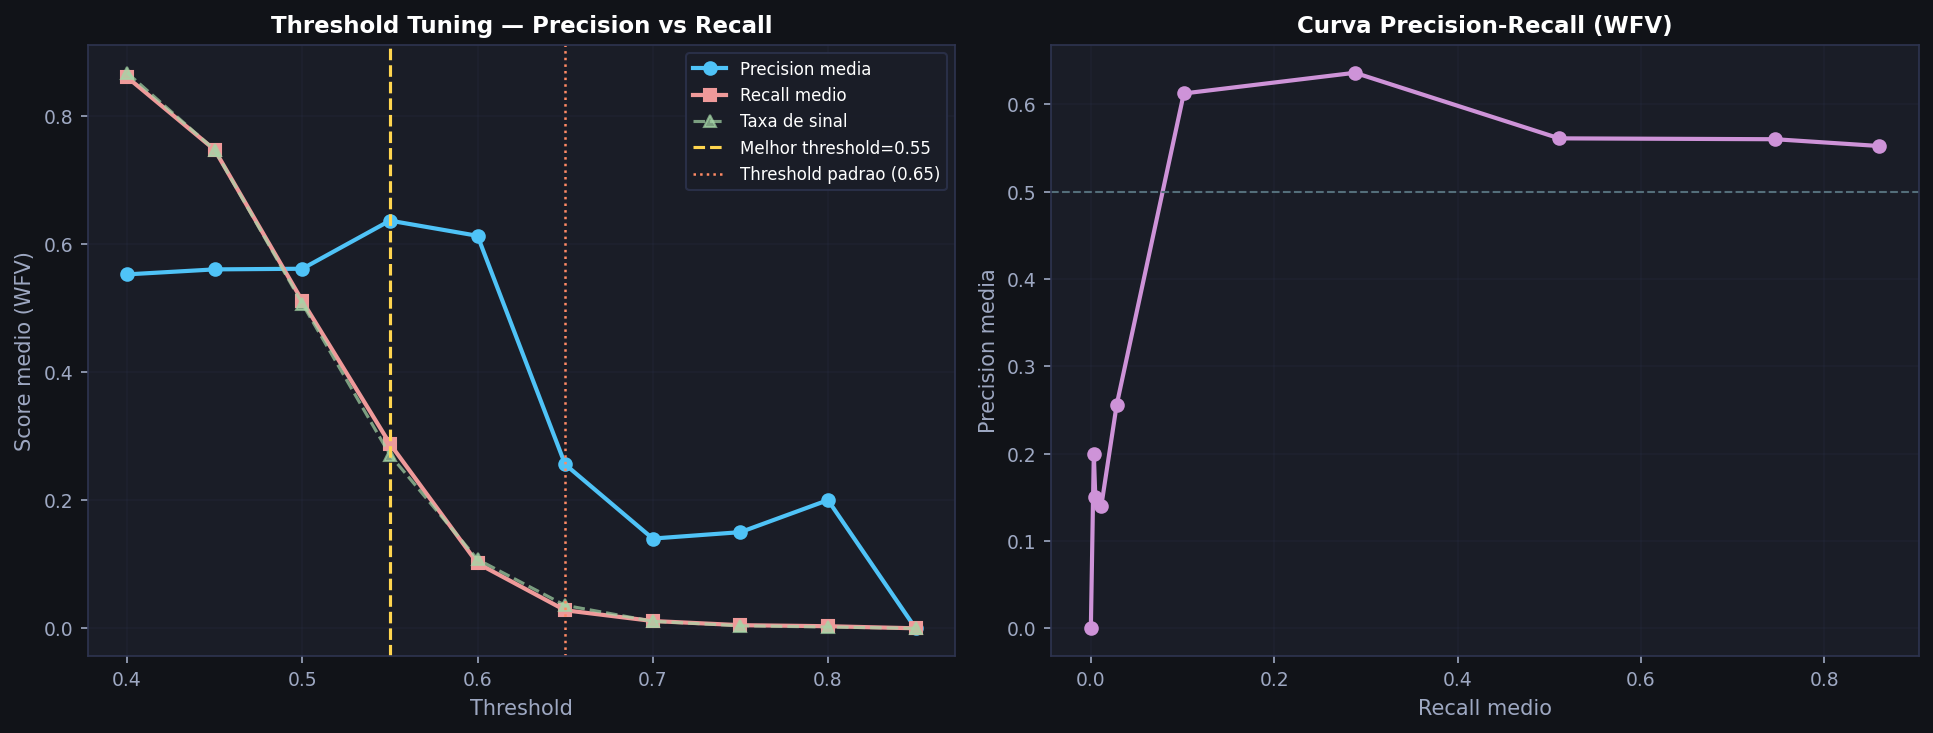

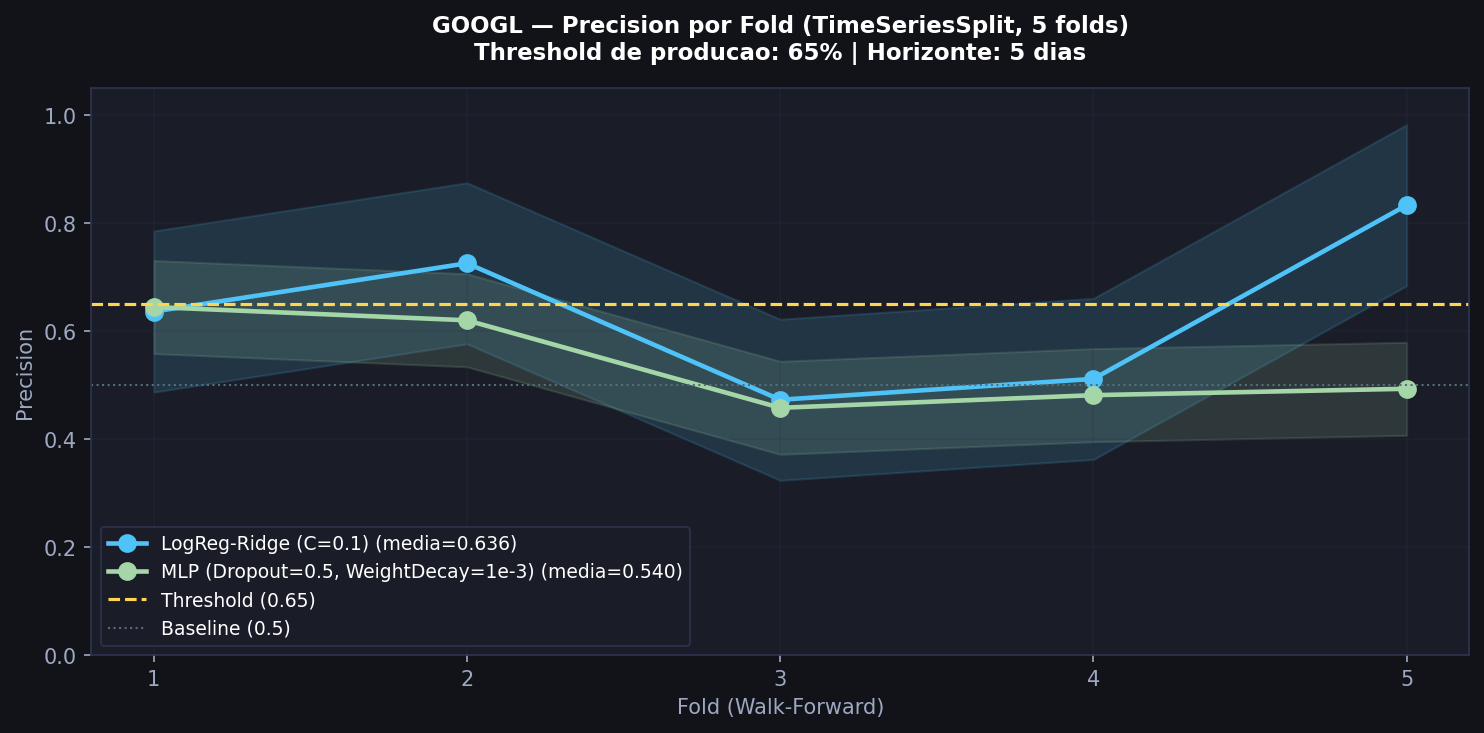

In [13]:
if best_threshold != SIGNAL_THRESHOLD:
    print(f'Re-avaliando com o threshold otimizado ({best_threshold:.2f})...')
    results_tuned = {}
    lr_tuned = walk_forward_validate(
        df_feat, model_factory=LogisticRidgeModel,
        n_splits=N_SPLITS, threshold=best_threshold,
    )
    results_tuned[LogisticRidgeModel().name] = lr_tuned
    if TORCH_AVAILABLE:
        feature_cols = [c for c in FEATURE_COLS if c in df_feat.columns]
        n_feat = len(feature_cols)
        mlp_tuned = walk_forward_validate(
            df_feat, model_factory=lambda: MLPModel(n_feat),
            n_splits=N_SPLITS, threshold=best_threshold,
        )
        results_tuned[MLPModel(n_feat).name] = mlp_tuned
    print_summary_table(results_tuned)
    results_all = results_tuned

plot_walkforward_precision(
    results_all,
    company=DEFAULT_COMPANY,
    save_path=f'{DEFAULT_COMPANY}_walkforward_precision.png',
)

# Exibir os gráficos inline no notebook
from IPython.display import Image, display
print('\n--- GRÁFICOS RESULTANTES DO PÓS-PROCESSO ---')
display(Image(filename=f'{DEFAULT_COMPANY}_threshold_tuning.png'))
display(Image(filename=f'{DEFAULT_COMPANY}_walkforward_precision.png'))